## Bonding sites

The simulation is run for 50000+1000000 timesteps. A total of 300 molecules are used, and each has 4 bonding sites.

## Potential function for patch-bead combination
The potential function, when the patch-bead pairs approach each other patch-first, are
$$
V(r) = \text{LJ}(r) + \text{Gaussian}(r)
$$
where
$$
\text{LJ}(r) = \begin{cases} 
    4 \epsilon \left[\left(\frac \sigma {r+x_0} \right)^{12} - \left(\frac \sigma {r+x_0} \right)^{6} \right] & r < r_c + x_0 \\
    0 & 0\leq r_c + x_0\\
\end{cases}
$$
and the cutoff distance has been calculated as the point where the potential is 0.
The Gaussian is defined as 
$$
\text{Gaussian}(r) = -A\exp{\left(- \frac {r^2} {2 \sigma_G^2}\right)}
$$
and the prefactor $A$ is considered an energy scale for the depth of the potential well. Note that, in the region where the Gaussian is effective, the WCA repulsion is also effective. Changing $A$ also moves the position of the minimum, although for most reasonable values this remains below $r=1.3$, which is the size of our beads.

There were some issues with the proper definition of the variance or standard deviation of the Gaussian. Per our results previously, the most reasonable value is $\sigma_G^2 = 0.19$.

The two parameters varied are $A$ and $x_0$. The latter is the distance between the bead and the patch. This is assumed to be constant for the purposes of the analysis, and starts with the value $x_0=0.45$

# Varying energy ($A$)

Varying the factor in front of the Gaussian varies depth of the potential well. Also varies the shape of the potential function slightly, which is reflected in the bond lengths below.

## Bond length

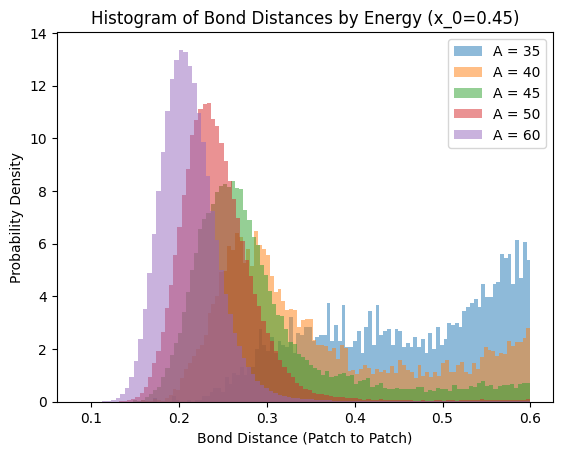

In [49]:
# histogram of bond distances

energies = [50, 60, 70, 80, 90, 100, 110]
energies = [35, 40, 45, 50, 60]




import matplotlib.pyplot as plt
import pandas as pd

for energy in energies:
    file = f'data/amine_bonds_{energy}.csv'
    data = pd.read_csv(file, skiprows=1, delimiter=' ', names=['timestep', 'id1', 'id2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'distance'])
    plt.hist(data['distance'], bins=100, density=True, label=f'A = {energy}', alpha=0.5)

plt.xlabel('Bond Distance (Patch to Patch)')
plt.ylabel('Probability Density')
plt.title('Histogram of Bond Distances by Energy (x_0=0.45)')
plt.legend()
plt.xlabel('Bond Distance (Patch to Patch)')
plt.ylabel('Probability Density')
plt.show()


As expected, the deeper the potential well the smaller the bond length on average -- increasing the potential also moves the well closer to zero. This does definitely serve to manipulate the bond distance between the two patches.

Let's also see the difference of where multiple bonds are in bond length, triple is expected to be higher as there is more steric hindrance for the closer bond lengths.

In [44]:
# TODO: add in different bond order vs length analysis

## Number of bonds over time

The number of bonds may change over time, which would imply that the system has not reached bond saturation/equilibrium. This would affect the bond distribution/behaviour. The system should be at equilibrium for us to judge it.

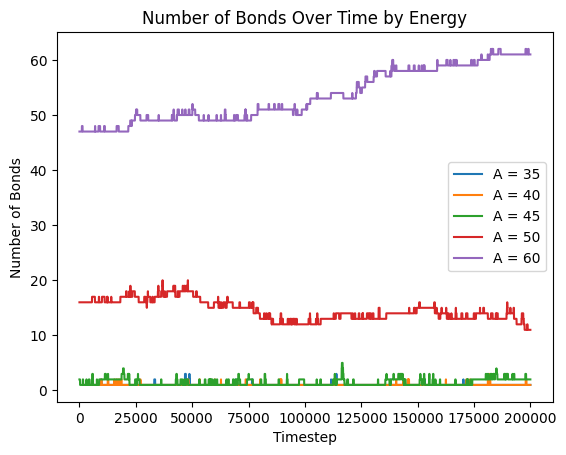

In [50]:
# plot number of bonds over time for each energy
for energy in energies:
    file = f'data/amine_bonds_{energy}.csv'
    data = pd.read_csv(file, skiprows=1, delimiter=' ', names=['timestep', 'id1', 'id2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'distance'])
    bond_counts = data['timestep'].value_counts().sort_index()
    plt.plot(bond_counts.index, bond_counts.values, label=f'A = {energy}')
plt.xlabel('Timestep')
plt.ylabel('Number of Bonds')
plt.title('Number of Bonds Over Time by Energy')
plt.legend()
plt.show()

It looks like they are for the most part at equilirium. Some of the higher energy do seem to still be equilibriating at the beginning but seem to  taper off by the 1/4 of the timesteps. 

We do see that the lower values of $A$ have far fewer counts of bonds.

## Multiple patch bonds

Multiple bonds are the issue with this model. There is an acceptance angle where two or more patches may approach a single patch and still be favourable. These are meant to be prevented by the steric hindrance of having two patches in a bond, where the two attached beads are preventing other patches from approaching. Therefore, we can reason that this effect is stronger if the patch-patch bond length is shorter -- the repulsions are stronger close to the bonded patch pair, and the incoming patch needs to get closer in order to be bonded.

It will be useful to calculate the probability of forming 3-patch bonds if there are currently 2-patch bonds. It may also be possible that 3-patch bonds occur when they are made at the same time. 

A = 35 - Average number of neighbours in multiplets: 1.0
A = 35 - Distribution of neighbours in multiplets:
num_neighbours
1.0    3030
Name: count, dtype: int64
A = 40 - Average number of neighbours in multiplets: 1.0
A = 40 - Distribution of neighbours in multiplets:
num_neighbours
1.0    7300
Name: count, dtype: int64
A = 45 - Average number of neighbours in multiplets: 1.0
A = 45 - Distribution of neighbours in multiplets:
num_neighbours
1.0    27064
Name: count, dtype: int64
A = 50 - Average number of neighbours in multiplets: 1.0
A = 50 - Distribution of neighbours in multiplets:
num_neighbours
1.0    290691
Name: count, dtype: int64
A = 60 - Average number of neighbours in multiplets: 1.0
A = 60 - Distribution of neighbours in multiplets:
num_neighbours
1.0    1068057
Name: count, dtype: int64


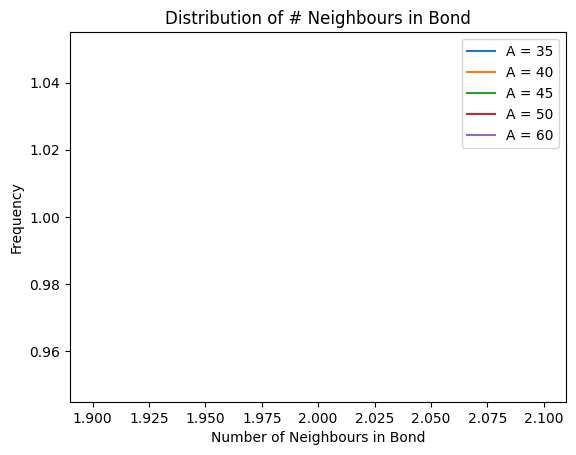

In [55]:
# TODO: calculate probability of forming 3-patch bonds if there are currently 2-patch bonds

import matplotlib.pyplot as plt

avg_neighbours = []
for energy in energies:
    try:
        file = f'data/amine_multiplets_{energy}.csv'
        data = pd.read_csv(file)
        data['num_neighbours'] = (data.count(axis=1) - 2) / 4  # subtract timestep and center columns
        neighbour_counts = data['num_neighbours'].value_counts().sort_index()
        norm_counts = neighbour_counts / neighbour_counts.sum()
        # plt.hist(data['num_neighbours'].dropna(), bins=range(2, 12), alpha=0.5, label=f'Energy {energy}', align='left')
        plt.plot(range(2, len(norm_counts) + 2), norm_counts, label=f'A = {energy}')
        print(f"A = {energy} - Average number of neighbours in multiplets:", data['num_neighbours'].mean())
        avg_neighbours.append(data['num_neighbours'].mean())
        print(f"A = {energy} - Distribution of neighbours in multiplets:")
        print(data['num_neighbours'].value_counts().sort_index())
    except FileNotFoundError:
        print(f"File not found for energy {energy}, skipping.")
plt.xlabel('Number of Neighbours in Bond')
plt.ylabel('Frequency')
plt.title('Distribution of # Neighbours in Bond')
plt.legend()
plt.show()

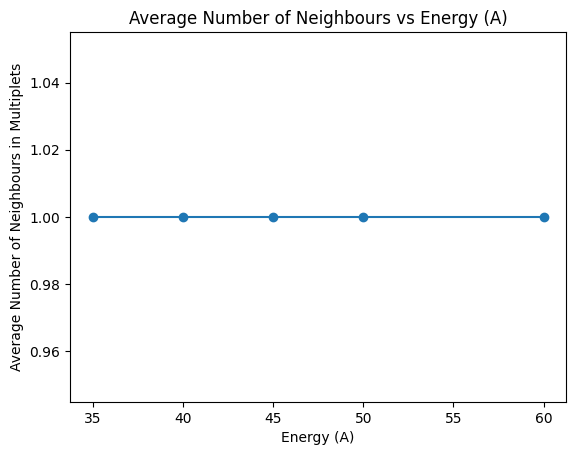

In [56]:
# graph average number of bonds

import matplotlib.pyplot as plt

plt.plot(energies, avg_neighbours, marker='o')
plt.xlabel('Energy (A)')
plt.ylabel('Average Number of Neighbours in Multiplets')
plt.title('Average Number of Neighbours vs Energy (A)')
plt.show()

Average bond lifetime for A=35: 31.894736842105264
[ 80  20  20  40 100  60  80  10  50  30  30  20  50  10  20  50  10  40
  30   0  10  40   0  20  10   0  20   0   0   0   0  10   0   0  10   0
   0   0   0  10   0   0  10  20   0  10   0   0   0   0  10   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0  10   0   0   0
   0   0   0   0   0   0   0   0   0  10]


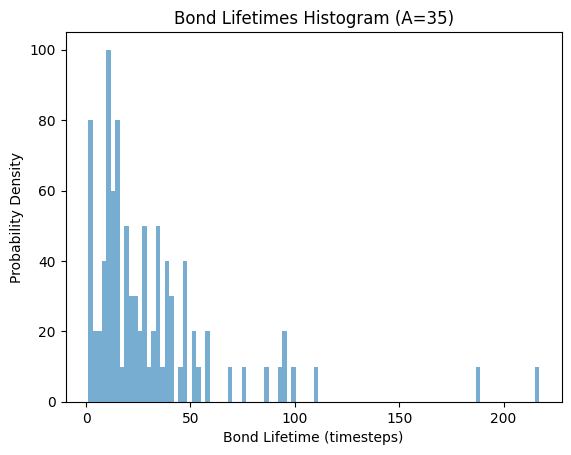

Average bond lifetime for A=40: 67.5925925925926
[560 200 110  60  40  20  10   0  10   0  10   0   0   0  10   0   0   0
   0   0  10   0   0   0  10   0   0   0   0   0   0   0   0   0   0   0
   0  10   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  10
   0   0   0   0   0   0   0   0   0  10]


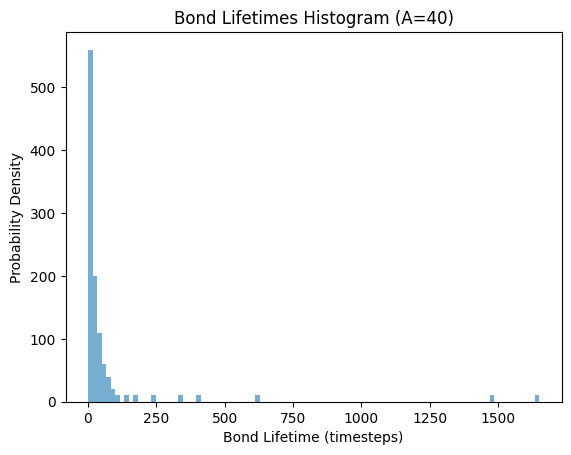

Average bond lifetime for A=45: 241.64285714285714
[520 290 100  30  40  10   0  10  20  10   0   0   0  10   0   0   0   0
   0  10   0   0  10   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0  10   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  10   0   0   0   0   0   0   0   0   0   0   0  10   0   0   0   0
   0   0   0   0   0   0   0   0   0  10]


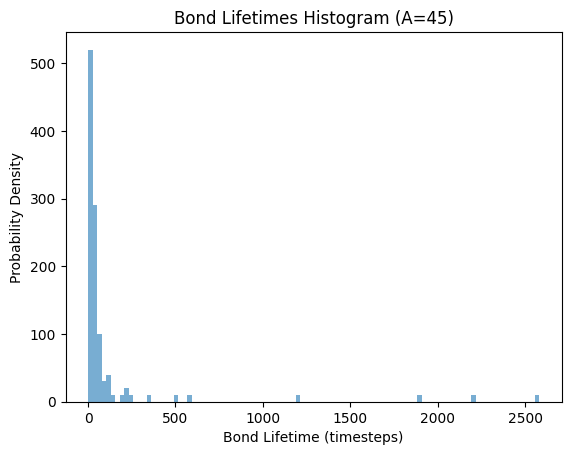

Average bond lifetime for A=50: 2076.364285714286
[800 180  60  40   0  10   0  20  10   0   0   0   0   0   0  10   0   0
  10   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0  10   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0  10   0   0   0   0   0  10   0
   0   0   0   0   0   0   0   0  10   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0  10]


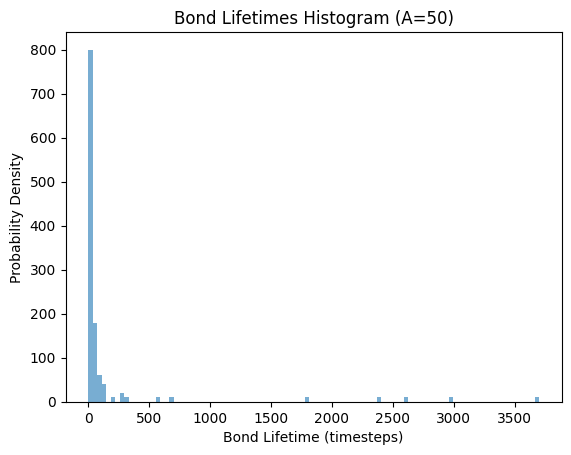

Average bond lifetime for A=60: 7315.458904109589
[360 200  80  50  20  50  10   0  10   0   0   0   0  10   0  10   0   0
   0   0   0   0   0   0   0   0   0   0   0  10   0   0   0   0   0   0
   0   0  10   0   0   0   0   0  10   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0  10   0   0   0   0  10]


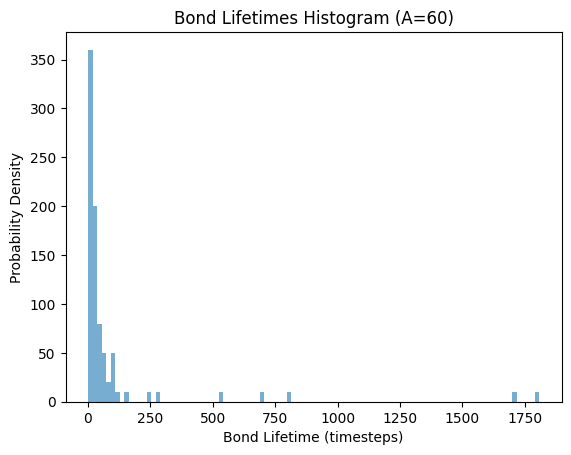

In [48]:
import numpy as np


def plot_bond_lifetimes(bond_lifetimes, title='Bond Lifetimes Histogram'):
    """
    Plot histogram of bond lifetimes.
    Parameters:
        bond_lifetimes (pd.DataFrame): DataFrame containing bond lifetimes
    """

    all_lifetimes = bond_lifetimes['lifetime']
    max_cutoff = 4000
    min_cutoff = 0
    filtered_data = all_lifetimes[(all_lifetimes < max_cutoff) & (all_lifetimes > min_cutoff)] 
    hist, _ = np.histogram(filtered_data, bins=100)

    plt.hist(filtered_data, bins=100, alpha=0.6, label='Data')
    plt.xlabel('Bond Lifetime (timesteps)')
    plt.ylabel('Probability Density')
    plt.title(title)
    print(hist)
    plt.show()

for energy in energies:
    file = f'data/bond_lifetimes_{energy}.csv'
    bond_lifetimes = pd.read_csv(file, delimiter=',')
    print(f"Average bond lifetime for A={energy}:", avg := bond_lifetimes['lifetime'].mean())
    plot_bond_lifetimes(bond_lifetimes, title=f'Bond Lifetimes Histogram (A={energy})')

Each bonded pair is grouped with the other bonded pairs such that an adjacency list is formed with each group accounting for all interconnected bonds.

The distribution graph was my initial attempt to tell at a glance which $A$ value works best. The most desirable would not appear on the graph at all -- if all the bonds are 2-patch, they wouldn't show up in the line plots. However, all of them have at least some 3-patch bonds. 

The best option is $A=50$, where there are only 2-, 3-patch bonds and there are far more 2-patch bonds than 3-. The proportion of 2-patch bonds is $\frac{5812}{(5812+107)} \approx 0.981$ which is the vast majority of the bonds. 

Similarly, $A=60$ is close with almost negligble amounts of 4-patch bonds (proportion $~0.00003$), with 2-patch bonds having a proportion of $~0.824$. Although this is a majority, there is a non-neglible amount of 3-patch bonds already. Greater $A$ values are worse.

This is a bit easier to see in the average number of neighbours plot. Here, the average starts at almost 2 and increases until a plateau past $A=100$. Generally, each subsequent greater $A$ value is worse with less 2-patch bonds in proportion to all the bonded groups.

# Varying patch-bead length ($x_0$)

Although not directly changing the Gaussian strength, moving the patch closer and further from the bead still affects the bond length and strength.

## Bond length

Once again, we can see the different bond lengths as a way to visualize the potential (is this true?).

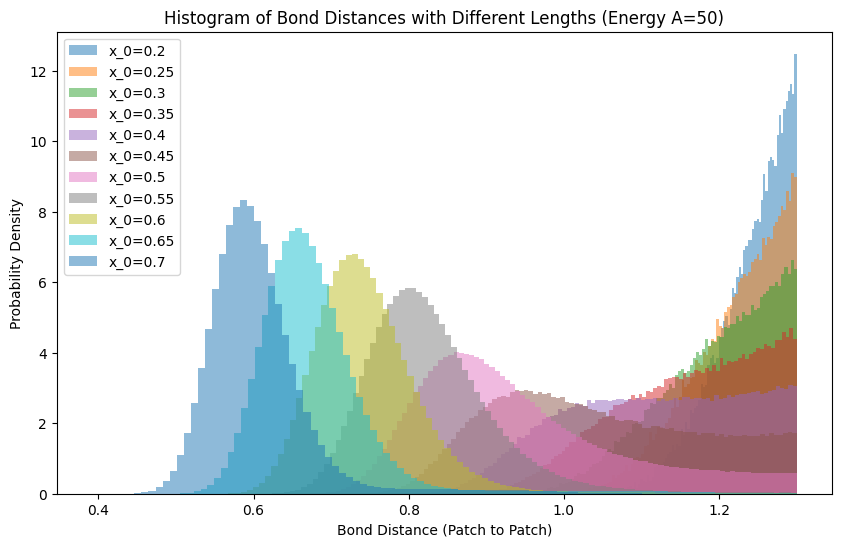

In [6]:
# histogram of bond distances

lengths = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

import matplotlib.pyplot as plt
import pandas as pd

figure = plt.figure(figsize=(10, 6))
for length in lengths:
    file = f'data/amine_bonds_length_{length}.csv'
    data = pd.read_csv(file, skiprows=1, delimiter=' ', names=['timestep', 'id1', 'id2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'distance'])
    plt.hist(data[data['timestep']>5000]['distance'], bins=100, density=True, label=f'x_0={length}', alpha=0.5)

plt.xlabel('Bond Distance (Patch to Patch)')
plt.ylabel('Probability Density')
plt.title('Histogram of Bond Distances with Different Lengths (Energy A=50)')
plt.legend()
plt.xlabel('Bond Distance (Patch to Patch)')
plt.ylabel('Probability Density')
plt.show()

(Note that the above is different from [Section 1.1](#Bond-length) as the Bond Distance cutoff is at 1.3, instead of 1.1)

Similar to varying energy, we get a spread of values that get more tightly peaked and closer to 0 as length decreases. As length $x=0$ increases, the Gaussian moves towards the other patch. The potential well also becomes deeper as there is less repulsion experienced at that bond length. At the very low lengths ($x_0~0.3$, close to bead size) the variance gets quite spread and it is, effectively, just the WCA repulsion that takes over. Note that the values closer to 1.3 begin to peak again because the graph is probability densities and the range of values is getting smaller.

## Number of bonds over time

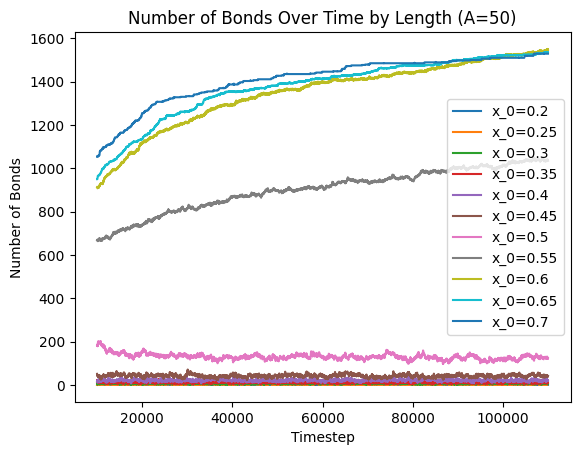

In [7]:
# plot number of bonds over time for each length
for length in lengths:
    file = f'data/amine_bonds_length_{length}.csv'
    data = pd.read_csv(file, delimiter=' ')
    bond_counts = data['timestep'].value_counts().sort_index()
    plt.plot(bond_counts.index, bond_counts.values, label=f'x_0={length}')
plt.xlabel('Timestep')
plt.ylabel('Number of Bonds')
plt.title('Number of Bonds Over Time by Length (A=50)')
plt.legend()
plt.show()

Only values of $x_0 > 0.5$ have any kind of change in number, the other values are all fairly consistent in the number of bonds. However, the other values do have a fairly low number of bonds in general. 

## Multiple patch bonds

Length 0.2 - Average number of neighbours in multiplets: 2.0
Length 0.2 - Distribution of neighbours in multiplets:
num_neighbours
2.0    103
Name: count, dtype: int64
Length 0.25 - Average number of neighbours in multiplets: 2.0
Length 0.25 - Distribution of neighbours in multiplets:
num_neighbours
2.0    219
Name: count, dtype: int64
Length 0.3 - Average number of neighbours in multiplets: 2.0
Length 0.3 - Distribution of neighbours in multiplets:
num_neighbours
2.0    583
Name: count, dtype: int64
Length 0.35 - Average number of neighbours in multiplets: 2.0025906735751295
Length 0.35 - Distribution of neighbours in multiplets:
num_neighbours
2.0    1155
3.0       3
Name: count, dtype: int64
Length 0.4 - Average number of neighbours in multiplets: 2.009806386723661
Length 0.4 - Distribution of neighbours in multiplets:
num_neighbours
2.0    3938
3.0      39
Name: count, dtype: int64
Length 0.45 - Average number of neighbours in multiplets: 2.017026988837078
Length 0.45 - Distributio

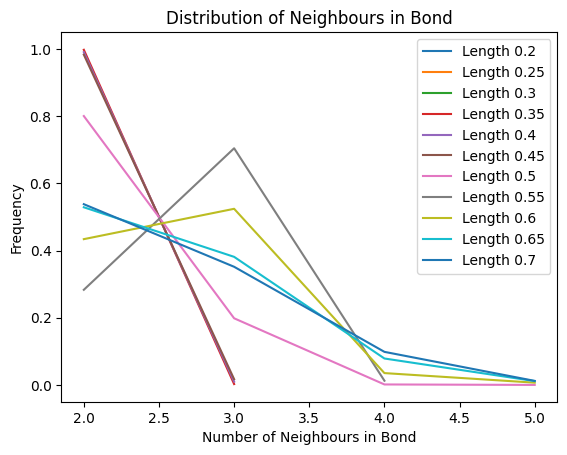

In [8]:
import matplotlib.pyplot as plt

avg_neighbours = []

for length in lengths:
    file = f'data/amine_multiplets_length_{length}.csv'
    data = pd.read_csv(file)
    data['num_neighbours'] = (data.count(axis=1) - 2) / 4  # subtract timestep and center columns
    neighbour_counts = data['num_neighbours'].value_counts().sort_index()
    norm_counts = neighbour_counts / neighbour_counts.sum()
    plt.plot(range(2, len(norm_counts) + 2), norm_counts, label=f'Length {length}')
    avg_neighbours.append(data['num_neighbours'].mean())
    print(f"Length {length} - Average number of neighbours in multiplets:", data['num_neighbours'].mean())
    print(f"Length {length} - Distribution of neighbours in multiplets:")
    print(data['num_neighbours'].value_counts().sort_index())
plt.xlabel('Number of Neighbours in Bond')
plt.ylabel('Frequency')
plt.title('Distribution of Neighbours in Bond')
plt.legend()
plt.show()



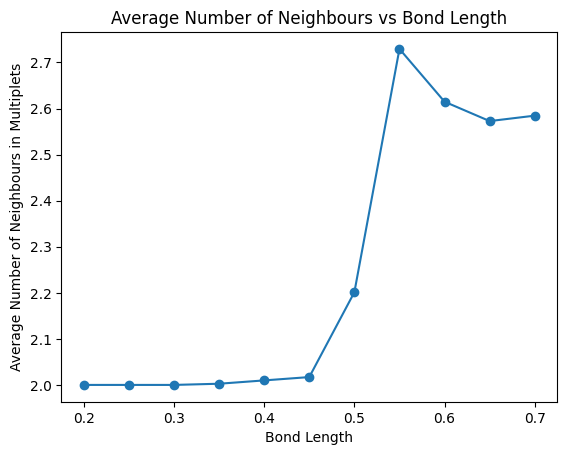

In [9]:
# graph average number of bonds

import matplotlib.pyplot as plt

plt.plot(lengths, avg_neighbours, marker='o')
plt.xlabel('Bond Length')
plt.ylabel('Average Number of Neighbours in Multiplets')
plt.title('Average Number of Neighbours vs Bond Length')
plt.show()

Similar to varying energy, the values where the potential is tightly peaked closer to 0, there are less patches in each bond. This is due to the lower acceptance angle when moving the Gaussian closer to the center of the WCA repulsion.

The values of average number of neighbours monotonically increases for the first couple values, ranging from $x_0=0.2$ with only 2-patch bonds, to $x_0=0.45$ with a proportion of about 0.983 for 2-patch bonds (note that this is the same case as $A=50, $x_0=0.45$ in Section 1). After that, the next length already approaches unfeasible proportions ($x_0=0.5$ with proportion of 2-patch bonds about 0.800). Another plateau occurs at high lengths.